## Handle OverBooking

Este proyecto tiene la finalidad de ayudar a Hoteles y empresas similares que gestionan sus reservas en Booking a evitar quedarse con habitaciones vacías, a través de estimar el overbooking en base a la probabilidad de cancelación de las reservas ya realizadas.

In [1]:
# Base de datos exploratoria, obtenida de Stack Overflow y guardad en la carpeta data en txt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la base de datos
df = pd.read_csv('../data/hotel_bookings.csv')

#Verificamos los valores nulos en el dataframe en 2 partes, primero de 0 a 20 y luego de 20 a 40
df.columns[0:20]
df.count()[0:20]


hotel                             119390
is_canceled                       119390
lead_time                         119390
arrival_date_year                 119390
arrival_date_month                119390
arrival_date_week_number          119390
arrival_date_day_of_month         119390
stays_in_weekend_nights           119390
stays_in_week_nights              119390
adults                            119390
children                          119386
babies                            119390
meal                              119390
country                           118902
market_segment                    119390
distribution_channel              119390
is_repeated_guest                 119390
previous_cancellations            119390
previous_bookings_not_canceled    119390
reserved_room_type                119390
dtype: int64

In [2]:
#Resto de columnas
df.columns[20:40]
df.count()[20:40]

assigned_room_type             119390
booking_changes                119390
deposit_type                   119390
agent                          103050
company                          6797
days_in_waiting_list           119390
customer_type                  119390
adr                            119390
required_car_parking_spaces    119390
total_of_special_requests      119390
reservation_status             119390
reservation_status_date        119390
dtype: int64

# Determinación de las variables

En base a lo observado, vamos a quitar las siguientes variables:

- agent: tiene nulos y no se considera reelevante para estimar la probabilidad de cancelación.
- reservation_status y reservation_status_date: Reflejan la misma información de la variable objetivo is_canceled y/o se gestionan al momento de ocurrir el evento.
- arrival_date_year: condiciona el modelo a tiempos pasados y evita generalizar.
- assigned_room_type: suele establecerse en el momento del checking físico por lo que no sería viable para predecir.

Variables a modificar:

- company: esta variable tiene sólo 6797 valores no nulos, pero de los 6797 que son company 5606 (82,48%) no se cancelaron, por lo que vamos a cambiar a la has_company (booleana).

In [3]:
# Demostración del porqué debemos modificar la variable company a has_company y que sea boleana.

df_company = df[df['company'].notnull()]

print("Cantidad de reservas canceladas (Solo Empresas):")
print(df_company['is_canceled'].value_counts())



Cantidad de reservas canceladas (Solo Empresas):
is_canceled
0    5606
1    1191
Name: count, dtype: int64


# Preparación del DataFrame final

In [4]:
# Primero agregamos al dataframe original la variable has_company como una variable boleana en base a company.
df['has_company'] = df['company'].notnull()

# Eliminamos la columna company del dataframe original y las columnas que no nos interesan para el análisis.
df = df.drop(['company', 'agent', 'reservation_status', 'reservation_status_date', 'arrival_date_year', 'assigned_room_type'], axis=1)

# Eliminamos todos los nulos del dataframe original
df = df.dropna()

df.info()

<class 'pandas.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  str    
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_month              118898 non-null  str    
 4   arrival_date_week_number        118898 non-null  int64  
 5   arrival_date_day_of_month       118898 non-null  int64  
 6   stays_in_weekend_nights         118898 non-null  int64  
 7   stays_in_week_nights            118898 non-null  int64  
 8   adults                          118898 non-null  int64  
 9   children                        118898 non-null  float64
 10  babies                          118898 non-null  int64  
 11  meal                            118898 non-null  str    
 12  country                         

## Split para entrenamiento

### Limpieza final antes del split

Antes de dividir en train/test revisamos un par de casos puntuales:

- `adr` (average daily rate) tiene un valor atípico extremo (5400) que distorsiona cualquier escalado.
- Hay filas con 0 huéspedes totales (`adults + children + babies == 0`), que no representan reservas reales.

In [5]:
print(f"Filas antes de limpiar: {len(df)}")

# Outlier extremo de adr
df = df[df['adr'] < 5000]

# Reservas sin huéspedes reales
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

print(f"Filas después de limpiar: {len(df)}")

Filas antes de limpiar: 118898


Filas después de limpiar: 118727


### Chequeo de leakage: `deposit_type`

Antes de entrenar, vale la pena mirar `deposit_type` de cerca: en este dataset es conocido que la categoría `Non Refund` está asociada a una tasa de cancelación anormalmente alta (~99%), un artefacto del dataset (proviene casi en su totalidad de un mismo segmento/mercado). No lo vamos a quitar —es una variable disponible al momento de la reserva, no es leakage técnico como `reservation_status`— pero lo dejamos documentado porque puede dominar la predicción y conviene explicarlo en la defensa.

In [6]:
deposit_ct = pd.crosstab(df['deposit_type'], df['is_canceled'], normalize='index') * 100
deposit_ct.columns = ['% no cancelado', '% cancelado']
print(deposit_ct)

              % no cancelado  % cancelado
deposit_type                             
No Deposit         71.515390    28.484610
Non Refund          0.638210    99.361790
Refundable         77.777778    22.222222


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(y_train.value_counts(normalize=True))

Train: (94981, 26), Test: (23746, 26)
is_canceled
0    0.628252
1    0.371748
Name: proportion, dtype: float64


## Preprocesamiento

Todo el preprocesado vive dentro de un `ColumnTransformer` para que el mismo objeto (serializado con `joblib`) se use en el notebook y en la API — evitando que la lógica de transformación se duplique o se desincronice.

- Categóricas de baja cardinalidad → `OneHotEncoder(handle_unknown='ignore')`.
- `country` tiene ~177 valores distintos: usamos `OneHotEncoder` con `min_frequency`/`max_categories` para agrupar automáticamente los países poco frecuentes en una categoría `infrequent`, en vez de mapearlo a mano.
- Numéricas (incluida `has_company`, ya booleana/0-1) → `StandardScaler`.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_date_month',
]
country_feature = ['country']
numeric_features = [
    'lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'has_company',
]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('country', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01, max_categories=15), country_feature),
    ('num', StandardScaler(), numeric_features),
])

FEATURE_ORDER = categorical_features + country_feature + numeric_features
print(f"Total de features de entrada: {len(FEATURE_ORDER)}")

Total de features de entrada: 26


## Modelos y calibración

Entrenamos dos modelos: una regresión logística como baseline y un Random Forest. Evaluamos con las métricas clásicas de clasificación, pero el foco está en la **calibración**: la app va a *sumar* probabilidades de cancelación para estimar cuántas reservas extra aceptar, así que un modelo que diga "30% de probabilidad" tiene que acertar de verdad un 30% de las veces. Un AUC alto no garantiza eso — para eso miramos la curva de calibración (reliability diagram) y el Brier score.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import calibration_curve

results = {}

def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'brier_score': brier_score_loss(y_test, y_proba),
    }
    results[name] = metrics

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    return y_proba

def plot_calibration(curves: dict):
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectamente calibrado')
    for name, y_proba in curves.items():
        frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
        plt.plot(mean_pred, frac_pos, marker='o', label=name)
    plt.xlabel('Probabilidad media predicha')
    plt.ylabel('Fracción real de positivos')
    plt.title('Curva de calibración')
    plt.legend()
    plt.show()

In [10]:
# Baseline: regresión logística
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])
logreg_pipeline.fit(X_train, y_train)
proba_logreg = evaluate_model('LogisticRegression', logreg_pipeline, X_test, y_test)

--- LogisticRegression ---
accuracy: 0.8053
precision: 0.8006
recall: 0.6341
f1: 0.7077
roc_auc: 0.8860
brier_score: 0.1282
Matriz de confusión:
[[13524  1394]
 [ 3230  5598]]


In [11]:
# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        n_jobs=-1, random_state=42,
    )),
])
rf_pipeline.fit(X_train, y_train)
proba_rf = evaluate_model('RandomForest', rf_pipeline, X_test, y_test)

--- RandomForest ---
accuracy: 0.8776
precision: 0.8806
recall: 0.7759
f1: 0.8250
roc_auc: 0.9500
brier_score: 0.0877
Matriz de confusión:
[[13989   929]
 [ 1978  6850]]


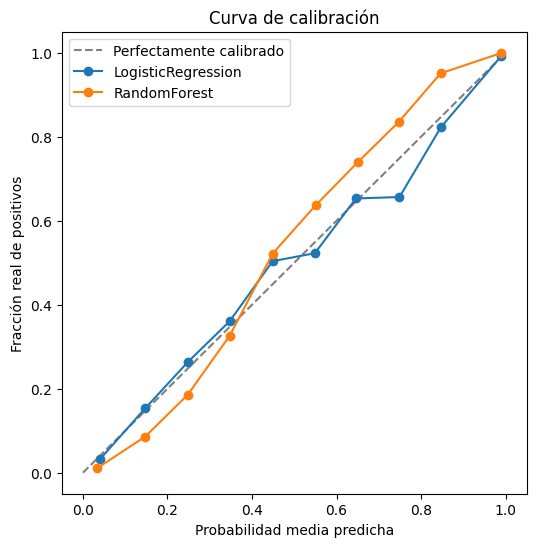

In [12]:
plot_calibration({'LogisticRegression': proba_logreg, 'RandomForest': proba_rf})

El Random Forest suele tener mejor discriminación (AUC) pero peor calibración "de fábrica" (tiende a comprimir las probabilidades hacia el centro). Lo envolvemos con `CalibratedClassifierCV` (calibración isotónica, 5-fold) y comparamos el Brier score y la curva de calibración antes/después.

--- RandomForest_calibrado ---
accuracy: 0.8767
precision: 0.8585
recall: 0.8003
f1: 0.8284
roc_auc: 0.9488
brier_score: 0.0862
Matriz de confusión:
[[13754  1164]
 [ 1763  7065]]


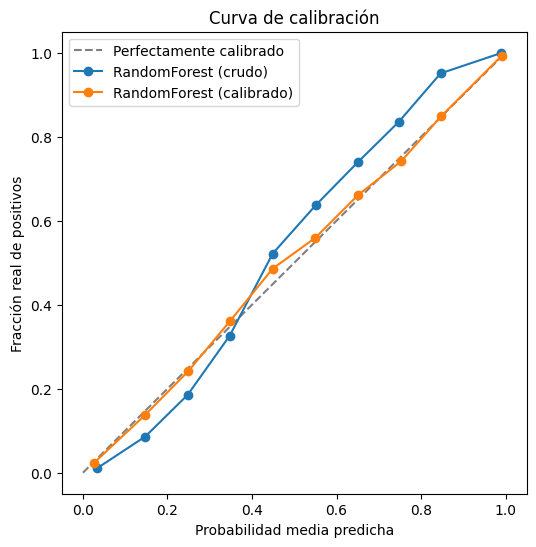

In [13]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CalibratedClassifierCV(
        RandomForestClassifier(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=42),
        method='isotonic', cv=5,
    )),
])
calibrated_rf_pipeline.fit(X_train, y_train)
proba_rf_calibrated = evaluate_model('RandomForest_calibrado', calibrated_rf_pipeline, X_test, y_test)

plot_calibration({'RandomForest (crudo)': proba_rf, 'RandomForest (calibrado)': proba_rf_calibrated})

In [14]:
comparison = pd.DataFrame(results).T
comparison = comparison.sort_values('brier_score')
print(comparison)

# El Random Forest calibrado (cv=5) es el que mejor Brier score tiene, pero como
# se ve más abajo, su artefacto es demasiado pesado para servirlo en la API.
print("\nMejor candidato por Brier score (referencia, no es el artefacto final que se despliega):")
print(comparison.index[0])

                        accuracy  precision    recall        f1   roc_auc  \
RandomForest_calibrado  0.876737   0.858549  0.800295  0.828399  0.948832   
RandomForest            0.877579   0.880576  0.775940  0.824953  0.950030   
LogisticRegression      0.805272   0.800629  0.634119  0.707712  0.886035   

                        brier_score  
RandomForest_calibrado     0.086239  
RandomForest               0.087730  
LogisticRegression         0.128206  

Mejor candidato por Brier score (referencia, no es el artefacto final que se despliega):
RandomForest_calibrado


### Artefacto final más liviano

`CalibratedClassifierCV(cv=5)` entrena y guarda **5 copias** del Random Forest (una por fold), lo que da un archivo `.joblib` de casi 1 GB — inviable para servir en la API. Para el modelo que se va a desplegar usamos calibración `prefit`: un único Random Forest (con profundidad acotada, para que el archivo sea manejable) entrenado en una porción de train, calibrado sobre una porción separada (sin tocar el test set).

--- RandomForest_calibrado_final ---
accuracy: 0.8527
precision: 0.8378
recall: 0.7488
f1: 0.7908
roc_auc: 0.9290
brier_score: 0.1022
Matriz de confusión:
[[13638  1280]
 [ 2218  6610]]


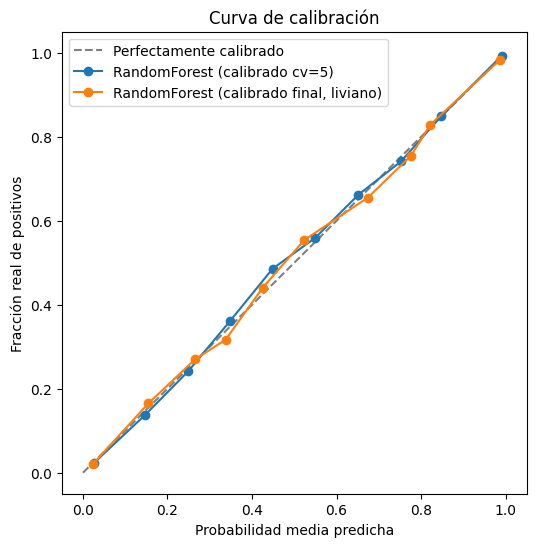

In [15]:
from sklearn.frozen import FrozenEstimator

X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

final_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('country', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01, max_categories=15), country_feature),
    ('num', StandardScaler(), numeric_features),
])

X_fit_transformed = final_preprocessor.fit_transform(X_fit, y_fit)
X_calib_transformed = final_preprocessor.transform(X_calib)

final_rf = RandomForestClassifier(
    n_estimators=150, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42,
)
final_rf.fit(X_fit_transformed, y_fit)

# En sklearn >= 1.6, cv='prefit' fue reemplazado por FrozenEstimator (el estimador ya entrenado
# se pasa "congelado" para que CalibratedClassifierCV solo ajuste el calibrador encima).
final_calibrated_clf = CalibratedClassifierCV(FrozenEstimator(final_rf), method='isotonic')
final_calibrated_clf.fit(X_calib_transformed, y_calib)

final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('classifier', final_calibrated_clf),
])

FINAL_MODEL_NAME = 'RandomForest_calibrado_final'
proba_final = evaluate_model(FINAL_MODEL_NAME, final_pipeline, X_test, y_test)
plot_calibration({
    'RandomForest (calibrado cv=5)': proba_rf_calibrated,
    'RandomForest (calibrado final, liviano)': proba_final,
})

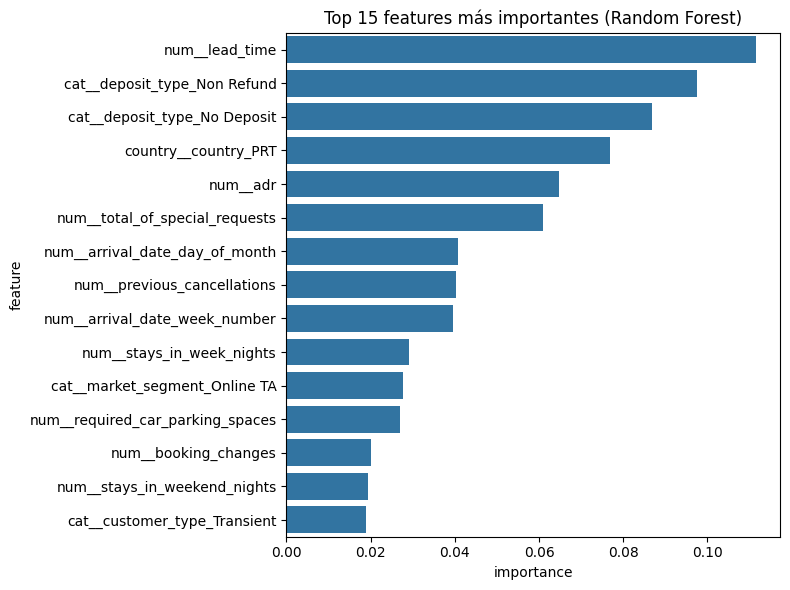

In [16]:
# Importancia de features (usamos el RF sin calibrar, que expone feature_importances_ directamente)
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Top 15 features más importantes (Random Forest)')
plt.tight_layout()
plt.show()

## Cálculo del overbooking

Para una fecha dada, el hotel tiene `n` reservas activas con probabilidades de cancelación calibradas `p_1, ..., p_n` (variables Bernoulli independientes). El número de cancelaciones es una variable aleatoria Poisson-binomial:

- Cancelaciones esperadas: `mu = Σ p_i`
- Varianza: `sigma² = Σ p_i · (1 - p_i)`

Aproximando esa suma por una normal (válido para `n` no muy pequeño), el número de reservas *extra* que se pueden aceptar manteniendo una probabilidad `alpha` de que sobre algún huésped es:

`overbooking = max(0, floor(mu - z_(1-alpha) * sigma))`

donde `z_(1-alpha)` es el cuantil de la normal estándar (por ejemplo `z_0.95 ≈ 1.645` para `alpha = 5%`). El `% de overbooking` recomendado es `overbooking / capacidad_del_hotel`.

In [17]:
import numpy as np
from scipy.stats import norm

def recommend_overbooking(probs, risk_alpha=0.05, total_rooms=None):
    """
    probs: array-like de probabilidades de cancelación de las reservas activas.
    risk_alpha: probabilidad aceptada de quedarse sin habitación para algún huésped.
    total_rooms: capacidad del hotel (opcional, para expresar el resultado en %).
    """
    probs = np.asarray(probs, dtype=float)
    mu = probs.sum()
    sigma = np.sqrt((probs * (1 - probs)).sum())
    z = norm.ppf(1 - risk_alpha)

    extra_bookings = max(0, int(np.floor(mu - z * sigma)))

    result = {
        'expected_cancellations': float(mu),
        'std_cancellations': float(sigma),
        'recommended_extra_bookings': extra_bookings,
    }
    if total_rooms:
        result['recommended_overbooking_pct'] = round(100 * extra_bookings / total_rooms, 2)
    return result

In [18]:
# Validamos la aproximación normal con una simulación Monte Carlo
rng = np.random.default_rng(42)
sample_probs = np.random.default_rng(0).uniform(0.05, 0.6, size=150)

n_simulations = 20_000
simulated_cancellations = rng.binomial(1, sample_probs, size=(n_simulations, len(sample_probs))).sum(axis=1)

approx = recommend_overbooking(sample_probs, risk_alpha=0.05)
monte_carlo_quantile = np.quantile(simulated_cancellations, 0.05)

print(f"Aproximación normal -> cancelaciones esperadas: {approx['expected_cancellations']:.2f}, "
      f"cuantil 5% aprox: {approx['expected_cancellations'] - norm.ppf(0.95) * approx['std_cancellations']:.2f}")
print(f"Monte Carlo (20,000 simulaciones) -> cuantil 5%: {monte_carlo_quantile:.2f}")

Aproximación normal -> cancelaciones esperadas: 51.86, cuantil 5% aprox: 42.87
Monte Carlo (20,000 simulaciones) -> cuantil 5%: 43.00


In [19]:
# Demo con una fecha real del test set: elegimos el día con más reservas activas
demo_dates = X_test.groupby(['arrival_date_month', 'arrival_date_day_of_month']).size().sort_values(ascending=False)
demo_month, demo_day = demo_dates.index[0]
mask = (X_test['arrival_date_month'] == demo_month) & (X_test['arrival_date_day_of_month'] == demo_day)

demo_probs = proba_final[mask.values]
demo_total_rooms = len(demo_probs)  # asumimos que la capacidad = reservas activas para este ejemplo

demo_result = recommend_overbooking(demo_probs, risk_alpha=0.05, total_rooms=demo_total_rooms)

print(f"Fecha demo: {demo_day} de {demo_month} -- {len(demo_probs)} reservas activas, capacidad {demo_total_rooms} habitaciones")
print(demo_result)

Fecha demo: 14 de August -- 139 reservas activas, capacidad 139 habitaciones
{'expected_cancellations': 71.22053627841174, 'std_cancellations': 3.9328523024585653, 'recommended_extra_bookings': 64, 'recommended_overbooking_pct': 46.04}


## Persistencia del modelo

Guardamos el pipeline completo (preprocesamiento + clasificador calibrado) con `joblib`, y un `model_metadata.json` con los valores categóricos permitidos (para validar los inputs en la API y poblar los desplegables del dashboard) y las métricas de test.

In [20]:
import json
import sklearn
import joblib
from datetime import datetime, timezone
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(final_pipeline, '../models/model_pipeline.joblib')

metadata = {
    'model_name': FINAL_MODEL_NAME,
    'trained_at': datetime.now(timezone.utc).isoformat(),
    'sklearn_version': sklearn.__version__,
    'feature_order': FEATURE_ORDER,
    'categorical_values': {
        col: sorted(X_train[col].dropna().unique().tolist())
        for col in categorical_features + country_feature
    },
    'numeric_features': numeric_features,
    'test_metrics': results[FINAL_MODEL_NAME],
}

with open('../models/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artefactos guardados en Model/models/")
print(f"- model_pipeline.joblib")
print(f"- model_metadata.json")

Artefactos guardados en Model/models/
- model_pipeline.joblib
- model_metadata.json


## Extra: umbral de tiempo desde la reserva

Idea: si una reserva lleva mucho tiempo hecha sin cancelarse, ¿es razonable asumir que ya no va a cancelar? Lo comprobamos con el CSV crudo (estas columnas **no** se usan como features de entrenamiento porque son leakage — `reservation_status_date` solo se conoce si la reserva ya canceló):

- `booking_date = arrival_date - lead_time` (fecha en la que se hizo la reserva).
- `days_to_cancel = reservation_status_date - booking_date`, solo para reservas canceladas.

Con eso construimos la curva empírica de "a los N días desde la reserva, ¿qué % de las cancelaciones ya ocurrió?" para poder declarar un umbral práctico.

In [21]:
raw_df = pd.read_csv('../data/hotel_bookings.csv')

arrival_date = pd.to_datetime(
    raw_df['arrival_date_year'].astype(str) + '-' +
    raw_df['arrival_date_month'] + '-' +
    raw_df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
)
booking_date = arrival_date - pd.to_timedelta(raw_df['lead_time'], unit='D')
status_date = pd.to_datetime(raw_df['reservation_status_date'])

cancel_mask = raw_df['reservation_status'] == 'Canceled'
days_to_cancel = (status_date[cancel_mask] - booking_date[cancel_mask]).dt.days
days_to_cancel = days_to_cancel[days_to_cancel >= 0]

print(f"Reservas canceladas analizadas: {len(days_to_cancel)}")
print(days_to_cancel.describe())

Reservas canceladas analizadas: 43017
count    43017.000000
mean        59.020875
std         82.227766
min          0.000000
25%          3.000000
50%         26.000000
75%         84.000000
max        584.000000
dtype: float64


50% de las cancelaciones ocurren dentro de los primeros 26 días desde la reserva
80% de las cancelaciones ocurren dentro de los primeros 103 días desde la reserva
90% de las cancelaciones ocurren dentro de los primeros 167 días desde la reserva
95% de las cancelaciones ocurren dentro de los primeros 258 días desde la reserva


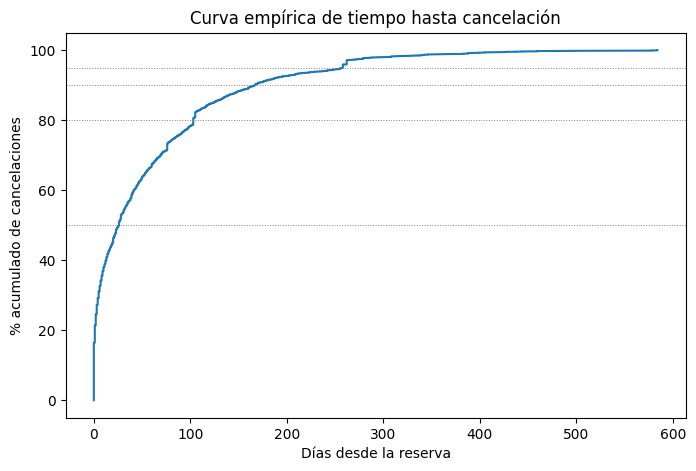

In [22]:
# Curva empírica: % de cancelaciones ya ocurridas a los N días desde la reserva
sorted_days = np.sort(days_to_cancel.values)
cum_pct = np.arange(1, len(sorted_days) + 1) / len(sorted_days) * 100

plt.figure(figsize=(8, 5))
plt.plot(sorted_days, cum_pct)
for pct in (50, 80, 90, 95):
    day_at_pct = np.percentile(sorted_days, pct)
    plt.axhline(pct, color='gray', linestyle=':', linewidth=0.7)
    print(f"{pct}% de las cancelaciones ocurren dentro de los primeros {day_at_pct:.0f} días desde la reserva")
plt.xlabel('Días desde la reserva')
plt.ylabel('% acumulado de cancelaciones')
plt.title('Curva empírica de tiempo hasta cancelación')
plt.show()

In [23]:
# Exportamos percentiles como referencia heurística (no se usa dentro del modelo, es un ajuste opcional para la API)
hazard_table = {
    'description': (
        'Percentiles empíricos de dias_desde_la_reserva a los que ocurre una '
        'cancelacion, calculados sobre reservas historicamente canceladas. '
        'Uso sugerido: si una reserva activa ya supero el percentil 90 sin '
        'cancelarse, su probabilidad residual de cancelar es baja.'
    ),
    'percentiles_days': {
        str(p): float(np.percentile(sorted_days, p)) for p in (50, 75, 80, 90, 95, 99)
    },
}

with open('../models/hazard_table.json', 'w', encoding='utf-8') as f:
    json.dump(hazard_table, f, ensure_ascii=False, indent=2)

print(hazard_table)

{'description': 'Percentiles empíricos de dias_desde_la_reserva a los que ocurre una cancelacion, calculados sobre reservas historicamente canceladas. Uso sugerido: si una reserva activa ya supero el percentil 90 sin cancelarse, su probabilidad residual de cancelar es baja.', 'percentiles_days': {'50': 26.0, '75': 84.0, '80': 103.0, '90': 167.0, '95': 258.0, '99': 383.0}}
